# 🎬 Byte's World — Image Generation Server

Runs **SDXL + Canopus-Pixar-Art LoRA** on Colab's free T4 GPU.  
Uses **Cloudflare Tunnel** (no account, no signup, completely free).

## Steps:
1. **Runtime → Change runtime type → T4 GPU**
2. Run Cell 1 (install), Cell 2 (load model), Cell 3 (test image)
3. Run Cell 4 — look for the line starting with `https://` and ending in `.trycloudflare.com`
4. Send that URL to Builder


In [1]:
# Cell 1: Install dependencies (no ngrok — using Cloudflare tunnel instead)
!pip install -q diffusers transformers accelerate safetensors \
              fastapi uvicorn nest-asyncio Pillow

# Install cloudflared (free tunnel, no account needed)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1
print('✅ Dependencies installed')

✅ Dependencies installed


In [2]:
# Cell 2: Load SDXL + Canopus-Pixar-Art LoRA
import torch
from diffusers import StableDiffusionXLPipeline, EulerAncestralDiscreteScheduler

print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (slow!)"}' )

print('Loading SDXL base (~5 min first time)...')
pipe = StableDiffusionXLPipeline.from_pretrained(
    'stabilityai/stable-diffusion-xl-base-1.0',
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant='fp16',
)
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

print('Loading Canopus-Pixar-Art LoRA...')
pipe.load_lora_weights(
    'prithivMLmods/Canopus-Pixar-Art',
    weight_name='Canopus-Pixar-Art.safetensors',
    adapter_name='pixar',
)
pipe.set_adapters('pixar')

# Cast everything to float16 AFTER LoRA load (fixes dtype mismatch)
pipe = pipe.to(torch.float16).to('cuda')

print('✅ Model ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU: Tesla T4
Loading SDXL base (~5 min first time)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Loading Canopus-Pixar-Art LoRA...


Canopus-Pixar-Art.safetensors:   0%|          | 0.00/456M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/144 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/384 [00:00<?, ?it/s]

✅ Model ready!


Generating test image (~15s)...


  0%|          | 0/25 [00:00<?, ?it/s]

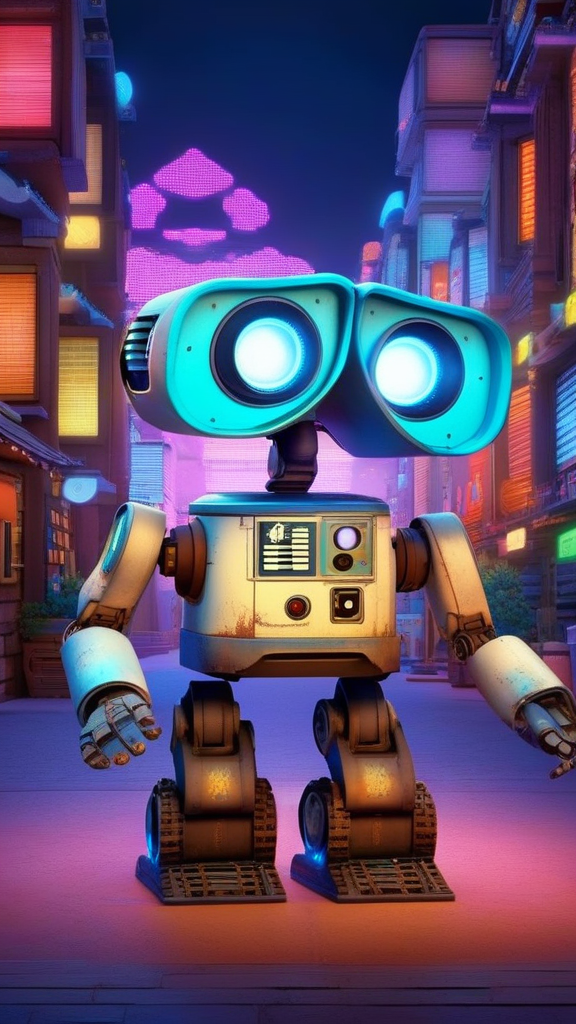

✅ Looking good! Run Cell 4 to start the server.


In [4]:
# Cell 3: Test image — confirm Pixar style works
from IPython.display import display

print('Generating test image (~15s)...')
with torch.inference_mode():
    result = pipe(
        prompt='3d image, Pixar style, small glowing round robot with cyan LED eyes, colorful digital city, cinematic lighting, vibrant colors',
        negative_prompt='ugly, deformed, bad anatomy, blurry, low quality, watermark, realistic photo',
        width=576,
        height=1024,
        num_inference_steps=25,
        guidance_scale=7.5,
    )
img = result.images[0]
display(img)
img.save('/content/test_byte.png')
print('✅ Looking good! Run Cell 4 to start the server.')

In [ ]:
# Cell 4: Start API server + Cloudflare tunnel (no account needed)
import base64, io, time, threading, subprocess, asyncio, re
import torch, nest_asyncio, uvicorn
from fastapi import FastAPI
from pydantic import BaseModel

nest_asyncio.apply()
app = FastAPI()

class GenReq(BaseModel):
    prompt: str
    negative_prompt: str = 'ugly, deformed, bad anatomy, blurry, low quality, watermark, realistic photo, nsfw'
    width: int = 576
    height: int = 1024
    steps: int = 25
    guidance_scale: float = 7.5

@app.get('/health')
def health():
    return {'status': 'ok', 'model': 'sdxl+canopus-pixar-art', 'device': 'cuda'}

@app.post('/generate')
def generate(req: GenReq):
    t0 = time.time()
    prompt = f'3d image, Pixar style, {req.prompt}, cinematic lighting, vibrant colors, family friendly'
    with torch.inference_mode():
        result = pipe(
            prompt=prompt,
            negative_prompt=req.negative_prompt,
            width=req.width,
            height=req.height,
            num_inference_steps=req.steps,
            guidance_scale=req.guidance_scale,
        )
    img = result.images[0]
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode()
    took = int((time.time() - t0) * 1000)
    print(f'  [{took}ms] {req.prompt[:70]}')
    return {'image_b64': b64, 'took_ms': took, 'model': 'sdxl+canopus-pixar-art'}

# Start FastAPI in background
threading.Thread(
    target=lambda: uvicorn.run(app, host='0.0.0.0', port=8765, log_level='warning'),
    daemon=True
).start()
time.sleep(2)  # wait for server to start

# Start Cloudflare tunnel (no account needed)
proc = subprocess.Popen(
    ['cloudflared', 'tunnel', '--url', 'http://localhost:8765'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# Parse the public URL from cloudflared output
public_url = None
print('Starting Cloudflare tunnel...')
for line in proc.stdout:
    if 'trycloudflare.com' in line:
        match = re.search(r'https://[\w-]+\.trycloudflare\.com', line)
        if match:
            public_url = match.group()
            break

print('\n' + '='*60)
print('🚀 SERVER READY — SEND THIS TO BUILDER:')
print('='*60)
print(f'\n   {public_url}\n')
print('='*60)
print('Leave this cell running. Builder will generate all 10 frames.')

# Keep alive — re-run if it times out
proc.wait()

Starting Cloudflare tunnel...

🚀 SERVER READY — SEND THIS TO BUILDER:

   https://comment-recommendation-florida-dim.trycloudflare.com

Leave this cell running. Builder will generate all 10 frames.
